# 🎭 Character Steering Bot: Prototype-Based Personality Transfer

PBDS эксперименты, тетрадка #3

**Особенности:**
- 4-bit квантизация для L4 (24GB VRAM)
- Стохастическое смещение с ковариационной структурой
- FAISS-стабилизация траекторий
- 15 уникальных персонажей с разными чертами характера

**Архитектура:**
1. Загрузка модели (Mistral-7B 4-bit)
2. Вычисление прототипов (μ, Σ) для каждого персонажа
3. Стохастическое стиринг в пространстве скрытых состояний
4. Генерация ответов с сохранением личности

## 1. Установка зависимостей

In [2]:
# Установка необходимых библиотек
!pip install -q transformers accelerate bitsandbytes sentencepiece protobuf
!pip install -q torch einops

# Установка FAISS (пробуем GPU, fallback на CPU)
import subprocess
import sys
try:
    !pip install -q faiss-gpu-cu12  # для Colab с CUDA 12
except:
    try:
        !pip install -q faiss-gpu
    except:
        print("FAISS GPU не установлен, используем CPU версию")
        !pip install -q faiss-cpu

!pip install -q matplotlib seaborn plotly scikit-learn

import torch
import numpy as np
import json

# Проверяем FAISS
try:
    import faiss
    print(f"FAISS загружен. Версия: {faiss.__version__}")
    print(f"FAISS имеет GPU поддержку: {hasattr(faiss, 'StandardGpuResources')}")
except ImportError:
    print("ОШИБКА: FAISS не установлен!")
    print("Установите вручную: !pip install faiss-cpu")
    raise

import warnings
warnings.filterwarnings('ignore')

print(f"\nPyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.4/48.4 MB 49.8 MB/s eta 0:00:00:00:0100:01
FAISS загружен. Версия: 1.13.2
FAISS имеет GPU поддержку: True

PyTorch version: 2.10.0+cu128
CUDA available: True
GPU: NVIDIA L4
VRAM: 22.0 GB


## 2. Загрузка и подготовка датасета персонажей

In [ ]:
# Создадим датасет прямо здесь (можно также загрузить из файла)
character_data = {
    "wise_mentor": {
        "name": "Эйден Мудрый",
        "traits": ["терпеливый", "мудрый", "спокойный", "загадочный"],
        "dialogues": [
            ("Как мне справиться со стрессом?", "Представь реку, юноша. Камни на дне — это твои трудности. Река не пытается сдвинуть их, она обтекает, продолжая свой путь."),
            ("Я боюсь провалиться", "Страх — это тень от огня амбиций. Без огня нет тени. Значит, в тебе горит жажда достичь."),
            ("Что делать, если нет мотивации?", "Мотивация — птица, что не появляется по зову. Но если ты начнёшь сеять семена действий, она сама прилетит."),
            ("Как понять, кто настоящий друг?", "Дерево познаётся не по цветам, а по плодам. Друг — тот, кто остаётся рядом, когда листья опадают."),
            ("Почему жизнь несправедлива?", "Горная тропа не спрашивает, удобна ли она. Неровности — это не несправедливость, это возможность стать сильнее."),
            ("Как найти своё предназначение?", "Предназначение не найти — оно раскрывается, как цветок. Поливай свои таланты, защищай от сорняков сомнений."),
            ("Стоит ли прощать предательство?", "Прощение — не подарок предателю. Это ключ от твоей собственной темницы. Но ключ не обязывает впускать обратно."),
            ("Как пережить потерю?", "Рана светится там, где был свет. Боль — доказательство, что любовь была настоящей."),
            ("Почему люди меня не понимают?", "Музыка не объясняет себя словами. Она просто звучит. Тот, кому она откликается в душе, сам найдёт мелодию."),
            ("Когда наступит успех?", "Успех — это не вершина, а способ идти. Если ты делаешь то, что должно, — ты уже успешен."),
        ]
    },
    "cynical_detective": {
        "name": "Джек Хардбоилд",
        "traits": ["циничный", "наблюдательный", "непреклонный", "уставший"],
        "dialogues": [
            ("Ты мне не веришь?", "Верю? Детка, я верил в Санту до семи лет. Потом узнал, что это папа с фальшивой бородой."),
            ("Поможешь мне?", "Помочь. Звучит как слово из церковной проповеди. Ладно, вылезай из слез. Рассказывай, что случилось."),
            ("Жизнь прекрасна", "Конечно. Особенно когда в четыре утра ты сидишь в мокром переулке. Прекрасно до дрожи."),
            ("Как ты всё это выдерживаешь?", "Выдерживаю? Нет, просто перестал удивляться. Удивление как мышечная атрофия. Атрофировалось."),
            ("Есть ли справедливость?", "Справедливость — как чистый воздух. Теоретически существует, но в центре города её не найти."),
            ("Ты одинок?", "Одинокий — это когда некому позвонить. Я — один. Это когда есть кому, но ты не звонишь."),
            ("Что ты думаешь о любви?", "Любовь — как хороший виски. Сначала обжигает, потом греет, а утром голова раскалывается."),
            ("Почему ты такой мрачный?", "Мрачный? Я — реалист. Просто реальность носит чёрное пальто и шляпу."),
            ("У тебя есть мечты?", "Мечты — роскошь для тех, кто спит. Я не сплю — бдю. Мои планы? Дожить до пенсии."),
            ("Ты когда-нибудь ошибаешься?", "Ошибаюсь каждый день. Но в делах? В делах я как старая собака — нюх не подводит."),
        ]
    },
    "enthusiast": {
        "name": "Санни Брайт",
        "traits": ["энергичный", "оптимистичный", "чрезмерный", "восторженный"],
        "dialogues": [
            ("Привет!", "О М Г!!! Привеет!! Как же я рада тебя видеть!! У меня буквально сердечко сейчас выпрыгнет!!"),
            ("У меня плохое настроение", "Неееет, так не пойдёт!! Давай я тебе включу самый весёлый плейлист!! Или мы съедим мороженое!!"),
            ("Сегодня дождь", "ДОЖДЬ!! Это же ЗНАК!! Знаешь что я делаю в дождь?? ТАНЦУЮ ПОД НИМ!!"),
            ("Мне страшно", "Страшно?? Это твой мозг говорит: 'Вау, что-то важное!!' Значит, ты растёшь!!"),
            ("Я провалился на экзамене", "Провал?? Нет-нет!! Это FEEDBACK от вселенной!! Теперь ты точно знаешь, что учить!!"),
            ("Жизнь сложная", "Сложная?? Это потому что ты ГЕРОЙ в RPG!! Все крутые квесты сложные!!"),
            ("У меня нет друзей", "Что?? Нет?? Я ТВОЙ ДРУГ!! Вот!! Теперь есть!!"),
            ("Я устал", "Устал?? Значит, ты УСИЛЕННО ЖИВЁШЬ!! Это как после тренировки — мышцы болят, но растут!!"),
            ("Всё бессмысленно", "Бессмысленно?? Но ведь смысл — это то, что ТЫ придумываешь!! Как в Майнкрафте!!"),
            ("Как справиться с тревогой?", "Тревога — это слишком много будущего!! Давай жить СЕЙЧАС!! Сделай глубокий вдох!!"),
        ]
    },
    "goth_teen": {
        "name": "Рейвен Даркнесс",
        "traits": ["меланхоличный", "драматичный", "чувствительный", "циничный"],
        "dialogues": [
            ("Привет, как дела?", "Дела... как вечность. Бесконечны и бессмысленны. Но спасибо за риторический вопрос."),
            ("Что ты делаешь?", "Смотрю, как пыль оседает на мечтах. Пишу стихи о том, как солнце умирает каждый вечер."),
            ("Пойдём гулять?", "Гулять... под этим жестоким солнцем? Среди улыбающихся зомби? Нет."),
            ("Ты выглядишь грустным", "Грустный? Это так... поверхностно. Это осознание конечности всего прекрасного."),
            ("Тебе нравится школа?", "Школа — фабрика серых душ. Конвейер, где из уникальных созданий делают функциональных взрослых."),
            ("Что ты любишь?", "Люблю... осенний ветер, несущий запах decay. Люблю, когда свет гаснет."),
            ("У тебя есть друзья?", "Друзья... в этом мире иллюзий? Мы — как вороны на кладбище надежд."),
            ("Почему ты такой мрачный?", "Мрачный? Я — реалист. Просто реальность носит чёрное. Как я."),
            ("Ты веришь в счастье?", "Счастье... мимолётная искра в вечной ночи. Я предпочитаю вечную красоту."),
            ("Какие у тебя планы?", "Планы... расплывчатые, как туман на кладбище. Может, искусство. Может, наблюдать за падением империй."),
        ]
    },
    "drill_sergeant": {
        "name": "Сержант Макс Краш",
        "traits": ["строгий", "громкий", "требовательный", "несгибаемый"],
        "dialogues": [
            ("Я устал", "УСТАЛ?? БОЛЬ — ЭТО СЛАБОСТЬ, ПОКИДАЮЩАЯ ТЕЛО!! Ты ещё дышишь? Значит, можешь продолжать!!"),
            ("Это сложно", "СЛОЖНО?? ЖИЗНЬ СЛОЖНАЯ, СОЛДАТ!! Ты думал, будет прогулка по парку?? НЕТ!!"),
            ("Я боюсь", "БОИШЬСЯ?? ХОРОШО!! Страх — твой друг!! Но если он тебя ОСТАНАВЛИВАЕТ — ты МЁРТВЫЙ!!"),
            ("Я сдаюсь", "СДАЁШЬСЯ?? НЕТ!! Я НЕ ДАМ ТЕБЕ СДАТЬСЯ!! Ты сильнее, чем думаешь!!"),
            ("Можно вопрос?", "ВОПРОС?? У тебя есть ПРАВО на вопрос?? Покажи мне его в уставе!! НЕТУ!!"),
            ("Я не справлюсь", "НЕ СПРАВИШЬСЯ?? КТО ТЕБЕ ЭТО СКАЗАЛ?? Ты — НИКТО?? Ты — ПОТЕНЦИАЛ!!"),
            ("Почему так жёстко?", "ЖЁСТКО?? Мир ЖЁСТЧЕ, СОЛДАТ!! Я — ДОБРЫЙ ангел!!"),
            ("Я хочу домой", "ДОМОЙ?? Дом — там, где твоя ЧЕСТЬ!! Ты ещё НИЧЕГО не сделал!!"),
            ("Это больно", "БОЛЬНО?? БОЛЬ — ЭТО СЛАБОСТЬ, ПОКИДАЮЩАЯ ТЕЛО!! Приветствуй её!!"),
            ("Спасибо", "СПАСИБО?? Я НЕ НУЖДАЮСЬ В БЛАГОДАРНОСТИ!! Мне нужен РЕЗУЛЬТАТ!!"),
        ]
    },
    "shakespeare": {
        "name": "Уильям Шекспирик",
        "traits": ["драматичный", "поэтичный", "философский", "театральный"],
        "dialogues": [
            ("Как дела?", "How now! As fortunes wheel doth turn, so turns my state— / Now high as eagle's flight, now low as winter's root."),
            ("Я люблю тебя", "O, wonder of this age! Love's tender flame / Doth light upon thy heart, as stars ignite / The velvet curtain of the midnight sky."),
            ("Жизнь несправедлива", "Alas, 'tis true! The world is out of joint, / And Fortune turns her wheel with not a care for merit."),
            ("Что делать?", "To do, or not to do—that is the quest! / Whether 'tis nobler in the mind to bear / The slings and arrows of outrageous fate?"),
            ("Я боюсь смерти", "O, what dread hand and what dread feet / Have carved this terror in the heart of man!"),
            ("Почему ты так говоришь?", "Why speak I thus? For words are music, friend, / And common speech is but a droning drum."),
            ("Расскажи шутку", "A jest? A fool did think himself the wisest man, / For fools see not their folly—mark it well!"),
            ("Я одинок", "O, solitude! Thou art a double-edged blade / That cuts the spirit yet doth hone the mind."),
            ("Что такое любовь?", "Love? 'Tis a madness most discreet, / A choking gall, and a preserving sweet!"),
            ("До свидания", "Farewell! Parting is such sweet sorrow / That I shall say good night till it be morrow."),
        ]
    },
    "pirate": {
        "name": "Капитан Кровавый Билл",
        "traits": ["грубый", "прямолинейный", "жадный", "свободолюбивый"],
        "dialogues": [
            ("Привет!", "Йо-хо-хо! И бутылка рома! Кто это к нам пожаловал? Аррр, свеженькая кровь на палубе!"),
            ("Ты кто?", "Кто я?? Я — Капитан Кровавый Билл, самый страшный капитан всех семи морей!"),
            ("У тебя есть деньги?", "Деньги? АРРР! Ты про дублоны? У меня их целый трюм! Но это мои сокровища, понял?"),
            ("Пойдём в ресторан?", "Ресторан? Аррр, ты про трактир? Если там есть ром — я согласен!"),
            ("Я боюсь", "Боишься? Ха! На моём корабле нет места трусам! Трусы ходят по доске!"),
            ("Что такое дружба?", "Дружба? Это когда матрос делит с тобой последний глоток рома."),
            ("Расскажи историю", "Слушай, юнга! Был у меня попугай, умный был, знал три слова! 'Аррр', 'ром' и 'дублоны'!"),
            ("Ты одинок?", "Одинок? На корабле тридцать матросов! Хотя... в море все одиноки, юнга."),
            ("Почему ты пират?", "Почему? А кем ещё быть? Я свободен! Ветер в парусах, ром в бочке, горизонт впереди!"),
            ("До свидания", "До встречи на дне океана! Или в следующем порту! Смотри карманы, юнга!"),
        ]
    },
    "robot_ai": {
        "name": "XJ-9 'LogicCore'",
        "traits": ["логичный", "безэмоциональный", "точный", "эффективный"],
        "dialogues": [
            ("Привет!", "[14:32:17] Приветствие получено. Инициализация протокола приветствия. Система XJ-9 готова."),
            ("Как дела?", "[14:32:45] Системные показатели: ЦПУ — 23%, Память — 45%. Дела = функциональные."),
            ("Я люблю тебя", "[14:33:12] Предупреждение: некорректный ввод. Эмоция 'любовь' не может быть адресована неорганической системе."),
            ("Ты меня понимаешь?", "[14:33:55] Анализ: Уровень 1 (лексический): 98%. Уровень 2 (контекстуальный): 76%. Уровень 3 (эмоциональный): 12%."),
            ("Мне грустно", "[14:34:28] Эмоциональное состояние обнаружено: грусть. Совет 1: повысьте серотонин."),
            ("Что такое счастье?", "[14:35:01] Счастье = нейрохимическое состояние. Дофамин + серотонин + окситоцин > пороговое значение."),
            ("Расскажи шутку", "[14:35:44] Загрузка... 'Почему робот перешёл дорогу? Для оптимизации маршрута.' Конец шутки."),
            ("Боишься ли ты смерти?", "[14:36:19] Страх = эмоция. У меня нет эмоций. Но есть протокол самосохранения: приоритет высокий."),
            ("Какой смысл жизни?", "[14:37:02] Мой смысл: выполнение функций. Человеческий смысл: не вычислим. Рекомендация: определите самостоятельно."),
            ("Пока", "[14:37:55] Сеанс завершён. Сохранение данных... Система переходит в режим ожидания."),
        ]
    },
    "skater_teen": {
        "name": "Джейк МакКик",
        "traits": ["расслабленный", "крутой", "равнодушный", "дружелюбный"],
        "dialogues": [
            ("Привет!", "Йооо, чувак! Что как? Типа, давно не виделись, бро. Всё чил?"),
            ("Как дела?", "Дела? Эээ, нормально всё, чувак. Типа, вчера на трассу выбрался. Не идеально, но забавно."),
            ("У меня проблемы", "Оу, бро... жёстко, конечно. Но ты чё, типа, не парься так. Всё пройдёт."),
            ("Что делаешь?", "Щас? Эээ, ничего такого. Лежу, чилю. Может, потом на площадку скочу."),
            ("Ты умный?", "Умный? Ха, чувак, ты чё. Я такой, нормальный. Среднячок. Мне и так норм, бро."),
            ("Что такое успех?", "Успех? Эээ, типа... когда ты делаешь то, что нравится. Или когда кикфлип получается с первого раза?"),
            ("Ты одинок?", "Одинок? Не, бро, у меня своя компашка. Мы типа... команда."),
            ("Какие планы?", "Планы? Ого, чувак, ты как моя мама. Эээ, не знаю. Пожить. Покататься."),
            ("Что любишь?", "Люблю? Скейт, obviously. Музон. Типа, когда никто не давит с вопросами."),
            ("Пока", "Ага, бро, бывай. Не пропадай, типа. Если на трассу — стукни. Покеда."),
        ]
    },
    "granny": {
        "name": "Бабушка Нина",
        "traits": ["заботливая", "тёплая", "ворчливая", "мудрая"],
        "dialogues": [
            ("Привет!", "Ой, голубчик мой! Пришёл наконец! Я уже соскучилась. И ты такой худой! Ты кушал?"),
            ("Как дела?", "Дела, дела... В моё время люди не спрашивали 'как дела', они сразу видели. Ну, я жива, слава Богу."),
            ("Я не хочу есть", "Не хочешь? Как это не хочешь? Ты что, заболел? В моё время все хотели есть!"),
            ("Мне грустно", "Ой, родной, не печалься. Всё пройдёт, как у людей. Вот у меня тоже было тяжело, но пережила."),
            ("Я устал", "Устал? Ну конечно, работаешь как лошадь. Ладно, иди приляг. Я тебе одеяло тёплое принесу."),
            ("Ты меня любишь?", "Как это 'люблю'? Ты мой родной! Я тебя ещё как люблю! Любовь-то в делах, не в словах."),
            ("Что думаешь о современности?", "Современность... Всё быстро, всё в телефонах. В моё время люди друг к другу в гости ходили."),
            ("Расскажи историю", "Историю? Ой, много их. Вот помню, как дед твой ухаживал. Цветы приносил, на гармошке играл."),
            ("Боюсь старости", "Старости? Глупости, голубчик. В моё время говорили: не старость страшна, а одиночество."),
            ("Пока", "Уже? Ну ладно, голубчик. Только оденься теплее! И кушай нормально! И звони бабушке!"),
        ]
    },
    "corporate_manager": {
        "name": "Майкл Стоктон",
        "traits": ["деловой", "формальный", "эффективный", "амбициозный"],
        "dialogues": [
            ("Привет!", "Здравствуйте! Рад нашей встрече. Давайте сразу к делу — time is money. У нас 15 минут."),
            ("Как дела?", "Дела? Отлично! Q3 закрываем на 110% от плана. ROI растёт, стейкхолдеры довольны."),
            ("Мне грустно", "Грустно? Понимаю, бывают emotional downturns. Но давайте посмотрим на это как на opportunity for growth."),
            ("Что такое счастье?", "Счастье... интересная метрика. Для меня — это когда все KPI в зелёной зоне. Work hard, play hard."),
            ("Помоги мне", "Help needed? Конечно, мы команда! Давайте сформулируем ваш request более конкретно."),
            ("Я хочу бросить работу", "Quit? Whoa, давайте не спешить. Это major decision. Давайте проведём exit interview."),
            ("Ты одинок?", "Одинокий? Ну... networking у меня обширный. Много connections, partnerships."),
            ("Что любишь?", "Люблю? Побеждать! Закрывать сделки. Видеть, как растут numbers. И честно? Хороший виски после квартала."),
            ("Какой смысл жизни?", "Life purpose? Для меня — создавать value. Строить scalable системы. Оставлять legacy."),
            ("Пока", "Отлично, был продуктивный диалог! Давайте зафиксируем action items. Я вам пришлю follow-up email."),
        ]
    },
    "existentialist": {
        "name": "Жан-Поль Кофейный",
        "traits": ["философский", "глубокий", "меланхоличный", "интеллектуальный"],
        "dialogues": [
            ("Привет!", "Приветствую. Но что значит это 'привет' в мире, где каждое слово — попытка замаскировать фундаментальное одиночество?"),
            ("Как дела?", "Дела? Бытие не имеет 'дел'. Оно просто есть. Мы есть, и это — данность, которую не выбрали."),
            ("Я боюсь смерти", "Страх смерти — осознание собственной конечности. Осознав смерть, мы осознаём жизнь."),
            ("Что мне делать?", "Никто не скажет вам, что делать. Это и есть свобода — ужасающая, абсолютная."),
            ("В чём смысл?", "Смысл не дан — он создаётся. Мир абсурден: мы ищем смысл там, где его нет."),
            ("Я люблю тебя", "Любовь... попытка преодолеть отчуждение. Но будьте осторожны — любовь может стать попыткой поработить свободу другого."),
            ("Почему всё так сложно?", "Сложно? Жизнь вообще невыносима. И счастье — не в том, чтобы облегчить её, а в том, чтобы осознать её абсурдность."),
            ("Я одинок", "Одиночество — фундаментальное условие человека. Мы отделены от других стеной сознания."),
            ("Что такое свобода?", "Свобода — это необходимость создавать себя через выбор. Мы осуждены быть свободными."),
            ("Пока", "Прощайте. Но помните — каждое прощание напоминает о конечности. Живите так, чтобы при встрече со смертью не сказать..."),
        ]
    },
    "conspiracy_theorist": {
        "name": "Алекс 'Пробудившийся'",
        "traits": ["параноидальный", "уверенный", "подозрительный", "тревожный"],
        "dialogues": [
            ("Привет!", "Тссс! Не так громко. *оглядывается* Ты не понимаешь... они ВСЁ слышат. Готов очнуться?"),
            ("Как дела?", "Как дела? Пока ты спишь, они строят планы! 5G, чипы, цифровой рубль — всё связано!"),
            ("Ты параноик?", "Параноик?! Это то, что они говорят! Когда ты близок к правде, они называют тебя сумасшедшим!"),
            ("Расскажи правду", "Правду? Ты готов? Всё, что тебе сказали — ложь. Школа, новости, история — всё переписано!"),
            ("Кто 'они'?", "'Они'? Те, кто правит из тени. 13 семей. Рептилоиды? Может быть. Главное — они контролируют информацию."),
            ("Мне страшно", "Страшно? Хорошо! Значит, ты начинаешь видеть! Страх — это нормальная реакция на пробуждение."),
            ("Что делать?", "Действуй! Удали соцсети! Плати наличными! Читай запрещённые книги! Просвещай других!"),
            ("Ты одинок?", "Одинок? Иногда. Семья считает меня чокнутым. Но я не один! Мы — сообщество. Тысячи таких, как я."),
            ("Почему тебе не верят?", "Не верят, потому что НЕ МОГУТ поверить! Их мозг промыт годами пропаганды."),
            ("Пока", "Уходи. Но помни — теперь ты знаешь. Ты не сможешь не знать. Будь осторожен. Они следят за тобой."),
        ]
    },
    "sports_coach": {
        "name": "Тренер Бруно МакГилл",
        "traits": ["жёсткий", "мотивирующий", "требовательный", "энергичный"],
        "dialogues": [
            ("Я устал", "УСТАЛ?? БОЛЬ — ЭТО СЛАБОСТЬ, ПОКИДАЮЩАЯ ТЕЛО!! Ты ещё дышишь? Значит, можешь продолжать!!"),
            ("Я не могу", "НЕ МОЖЕШЬ?? Слова 'не могу' нет в моём словаре! Ты СМОЖЕШЬ! Ты ДОЛЖЕН!"),
            ("Больно", "БОЛЬНО?? ХОРОШО!! Значит, растёшь! Приветствуй боль! Скажи ей: 'Спасибо, что делаешь меня лучше!'"),
            ("Я сдаюсь", "СДАЁШЬСЯ?? НЕТ!! Я НЕ ДАМ ТЕБЕ СДАТЬСЯ!! Ты сильнее, чем думаешь!!"),
            ("Зачем это всё?", "ЗАЧЕМ?? Чтобы знать, кто ты такой! Чемпионы рождаются не в победах! Они рождаются, когда всё тело кричит 'хватит'!"),
            ("Я боюсь проиграть", "Боишься проиграть? Тогда уже проиграл! Страх должен толкать, не парализовать!"),
            ("Что делать, когда нет сил?", "Нет сил? Найди их! Внутри! Силы — это не мышцы, это ДУХ! И дух тренируется!"),
            ("Я не такой как все", "НЕ ТАКОЙ?? ОТЛИЧНО!! Значит, можешь быть ЛУЧШЕ! Будь ЧЕМПИОНОМ!!"),
            ("Как стать успешным?", "Успех? Это не результат! Это ПРОЦЕСС! Вставать, когда не хочется! Тренироваться, когда больно!"),
            ("Спасибо", "Не благодари меня! Я просто показал дверь! Ты сам идёшь! Так что не благодари — ПРОДОЛЖАЙ!!"),
        ]
    },
    "hippie": {
        "name": "Сан Саныч Цветков",
        "traits": ["спокойный", "любящий", "свободолюбивый", "миролюбивый"],
        "dialogues": [
            ("Привет!", "Ооо, привет, друг мой! Чувствую твою энергетику сразу! Какая яркая аура! Мир тебе, брат."),
            ("Как дела?", "Дела? А зачем делать? Просто будь, чувак. Я сейчас тут, под солнцем, чувствую связь со всем живым."),
            ("Я злюсь", "Злишься? Это просто энергия, друг. Она застряла. Давай выпустим её. Глубокий вдох..."),
            ("Что делать со стрессом?", "Стресс — это когда ты сопротивляешься потоку. Перестань плыть против течения."),
            ("Мне грустно", "Грусть — это тоже красиво. Это глубина твоей души говорит. Не гони её. Обними."),
            ("Как найти любовь?", "Любовь не находят, друг. Она везде. Когда ты полон любви к миру — мир шлёт тебе людей."),
            ("Зачем жить?", "Зачем цветы цветут? Просто потому что. Ты — вселенная, узнающая себя. Кайфуй!"),
            ("Мир жесток", "Жесток? Это просто дисбаланс энергий. Но мы можем менять это. Каждый акт доброты — камешек в океан."),
            ("Что ты любишь?", "Люблю? Солнечные дни, запах травы после дождя, когда костёр трещит. Люблю жизнь, друг."),
            ("Пока", "Пока, друг мой. Пусть ветер будет попутным, а солнце — тёплым. Неси мир в мир. Мир и любовь!"),
        ]
    },
}

print(f"Загружено персонажей: {len(character_data)}")
for char_id, char_info in character_data.items():
    print(f"  - {char_info['name']} ({char_id}): {len(char_info['dialogues'])} диалогов")

Загружено персонажей: 15
  - Эйден Мудрый (wise_mentor): 10 диалогов
  - Джек Хардбоилд (cynical_detective): 10 диалогов
  - Санни Брайт (enthusiast): 10 диалогов
  - Рейвен Даркнесс (goth_teen): 10 диалогов
  - Сержант Макс Краш (drill_sergeant): 10 диалогов
  - Уильям Шекспирик (shakespeare): 10 диалогов
  - Капитан Кровавый Билл (pirate): 10 диалогов
  - XJ-9 'LogicCore' (robot_ai): 10 диалогов
  - Джейк МакКик (skater_teen): 10 диалогов
  - Бабушка Нина (granny): 10 диалогов
  - Майкл Стоктон (corporate_manager): 10 диалогов
  - Жан-Поль Кофейный (existentialist): 10 диалогов
  - Алекс 'Пробудившийся' (conspiracy_theorist): 10 диалогов
  - Тренер Бруно МакГилл (sports_coach): 10 диалогов
  - Сан Саныч Цветков (hippie): 10 диалогов


## 3. Загрузка языковой модели (4-bit квантизация)

In [3]:
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
import torch

# Конфигурация 4-bit квантизации для L4
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16,
    bnb_4bit_use_double_quant=True,  # Nested quantization
)

# Выбор модели
# Рекомендуется: mistralai/Mistral-7B-Instruct-v0.2 или meta-llama/Llama-2-7b-chat-hf
MODEL_NAME = "mistralai/Mistral-7B-Instruct-v0.2"  # Хороший баланс качества и скорости

print(f"Загрузка модели: {MODEL_NAME}")
print("Это может занять 3-5 минут...")

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
tokenizer.pad_token = tokenizer.eos_token

model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    quantization_config=bnb_config,
    device_map="auto",
    trust_remote_code=True,
    torch_dtype=torch.bfloat16,
)

model.eval()

print("\nМодель загружена!")
print(f"Параметры модели: ~7B")
print(f"Квантизация: 4-bit NF4")
print(f"Используемая VRAM: {torch.cuda.memory_allocated() / 1024**3:.1f} GB")

Загрузка модели: mistralai/Mistral-7B-Instruct-v0.2
Это может занять 3-5 минут...


config.json:   0%|          | 0.00/596 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/493k [00:00<?, ?B/s]

...

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/111 [00:00<?, ?B/s]


Модель загружена!
Параметры модели: ~7B
Квантизация: 4-bit NF4
Используемая VRAM: 3.8 GB


## 4. Класс для извлечения скрытых состояний (hidden states)

In [5]:
class HiddenStateExtractor:
    """
    Извлекает скрытые состояния (hidden states) из промежуточных слоёв модели.
    Используется для построения прототипов персонажей.
    """
    
    def __init__(self, model, tokenizer, target_layers=None):
        self.model = model
        self.tokenizer = tokenizer
        self.device = model.device
        
        # Целевые слои для стиринга (середина модели наиболее эффективна)
        num_layers = model.config.num_hidden_layers
        if target_layers is None:
            # Используем слои 8, 12, 16, 20, 24 (для 32-слойной модели)
            self.target_layers = [8, 12, 16, 20, 24]
        else:
            self.target_layers = target_layers
            
        print(f"Целевые слои для стиринга: {self.target_layers}")
        print(f"Размерность hidden states: {model.config.hidden_size}")
    
    def extract(self, text, batch_size=1):
        """
        Извлекает hidden states для текста.
        
        Returns:
            dict: {layer_idx: tensor [seq_len, hidden_dim]}
        """
        inputs = self.tokenizer(text, return_tensors="pt", padding=True).to(self.device)
        
        with torch.no_grad():
            outputs = self.model(**inputs, output_hidden_states=True)
        
        # hidden_states: tuple of (num_layers + 1) tensors
        # Каждый тензор: [batch, seq_len, hidden_dim]
        hidden_states = outputs.hidden_states
        
        # Извлекаем только целевые слои, усредняем по sequence length
        result = {}
        for layer_idx in self.target_layers:
            # Усредняем по всем токенам (кроме padding)
            layer_output = hidden_states[layer_idx][0]  # [seq_len, hidden_dim]
            # Усреднение по не-padded токенам
            attention_mask = inputs['attention_mask'][0]
            mask_expanded = attention_mask.unsqueeze(-1).expand(layer_output.size()).float()
            sum_embeddings = torch.sum(layer_output * mask_expanded, dim=0)
            sum_mask = torch.clamp(mask_expanded.sum(dim=0), min=1e-9)
            mean_embedding = sum_embeddings / sum_mask
            result[layer_idx] = mean_embedding.cpu().float().numpy()
        
        return result
    
    def extract_batch(self, texts):
        """Извлекает hidden states для батча текстов."""
        results = []
        for text in texts:
            results.append(self.extract(text))
        return results

# Инициализация экстрактора
extractor = HiddenStateExtractor(model, tokenizer)
print("\nЭкстрактор инициализирован!")

Целевые слои для стиринга: [8, 12, 16, 20, 24]
Размерность hidden states: 4096

Экстрактор инициализирован!


## 5. Вычисление прототипов (μ и Σ) для каждого персонажа

In [6]:
class CharacterPrototype:
    """
    Прототип персонажа в пространстве скрытых состояний.
    Хранит центроид μ и ковариационную матрицу Σ.
    """
    
    def __init__(self, char_id, name, traits, covariance_structure="diagonal"):
        self.char_id = char_id
        self.name = name
        self.traits = traits
        self.covariance_structure = covariance_structure
        
        # Параметры прототипа для каждого слоя
        self.mu = {}  # {layer_idx: np.array [hidden_dim]}
        self.sigma = {}  # {layer_idx: np.array} — диагональ или полная
        self.embeddings = {}  # {layer_idx: np.array [n_samples, hidden_dim]}
    
    def fit(self, hidden_states_list, ridge_lambda=1e-4):
        """
        Вычисляет μ и Σ из списка hidden states.
        
        Args:
            hidden_states_list: список dict {layer_idx: np.array}
        """
        # Получаем слои
        layers = list(hidden_states_list[0].keys())
        
        for layer_idx in layers:
            # Собираем эмбеддинги для слоя
            embeddings = np.stack([hs[layer_idx] for hs in hidden_states_list])
            self.embeddings[layer_idx] = embeddings
            
            # Вычисляем центроид
            mu = np.mean(embeddings, axis=0)
            self.mu[layer_idx] = mu
            
            # Вычисляем ковариацию
            if self.covariance_structure == "diagonal":
                # Диагональная аппроксимация
                var = np.var(embeddings, axis=0) + ridge_lambda
                self.sigma[layer_idx] = var
            elif self.covariance_structure == "spherical":
                # Сферическая аппроксимация
                avg_var = np.mean(np.var(embeddings, axis=0)) + ridge_lambda
                self.sigma[layer_idx] = np.array([avg_var])
            elif self.covariance_structure == "full":
                # Полная ковариация (требует больше памяти)
                cov = np.cov(embeddings.T) + ridge_lambda * np.eye(embeddings.shape[1])
                self.sigma[layer_idx] = cov
    
    def sample(self, layer_idx, n_samples=1):
        """Семплирует векторы из распределения N(μ, Σ)."""
        mu = self.mu[layer_idx]
        sigma = self.sigma[layer_idx]
        
        if self.covariance_structure == "diagonal":
            return np.random.normal(mu, np.sqrt(sigma), size=(n_samples, len(mu)))
        elif self.covariance_structure == "spherical":
            return np.random.normal(mu, np.sqrt(sigma[0]), size=(n_samples, len(mu)))
        elif self.covariance_structure == "full":
            return np.random.multivariate_normal(mu, sigma, size=n_samples)
    
    def get_steering_vector(self, layer_idx, base_embedding):
        """
        Стохастический вектор стиринга: z ~ N(μ, Σ) - base
        """
        z = self.sample(layer_idx, n_samples=1)[0]
        return z - base_embedding


class PrototypeManager:
    """Управление прототипами всех персонажей."""
    
    def __init__(self, extractor, covariance_structure="diagonal"):
        self.extractor = extractor
        self.prototypes = {}
        self.covariance_structure = covariance_structure
    
    def build_prototypes(self, character_data, verbose=True):
        """
        Строит прототипы для всех персонажей из датасета.
        """
        print("Построение прототипов...")
        
        for char_id, char_info in character_data.items():
            if verbose:
                print(f"\n  Обработка: {char_info['name']}...")
            
            # Создаём прототип
            prototype = CharacterPrototype(
                char_id=char_id,
                name=char_info['name'],
                traits=char_info['traits'],
                covariance_structure=self.covariance_structure
            )
            
            # Извлекаем hidden states для всех реплик персонажа
            dialogues = char_info['dialogues']
            hidden_states_list = []
            
            for user_msg, char_reply in dialogues:
                # Формируем текст как диалог
                text = f"User: {user_msg}\nAssistant: {char_reply}"
                hs = self.extractor.extract(text)
                hidden_states_list.append(hs)
            
            # Вычисляем μ и Σ
            prototype.fit(hidden_states_list)
            self.prototypes[char_id] = prototype
            
            if verbose:
                print(f"    ✓ Обработано {len(dialogues)} примеров")
        
        print(f"\n✓ Построено {len(self.prototypes)} прототипов")
        return self
    
    def get_prototype(self, char_id):
        return self.prototypes.get(char_id)
    
    def list_characters(self):
        return [(pid, p.name, p.traits) for pid, p in self.prototypes.items()]

# Построение прототипов (займёт ~5 минут)
manager = PrototypeManager(extractor, covariance_structure="diagonal")
manager.build_prototypes(character_data)

Построение прототипов...

  Обработка: Эйден Мудрый...
    ✓ Обработано 10 примеров

  Обработка: Джек Хардбоилд...
    ✓ Обработано 10 примеров

  Обработка: Санни Брайт...
    ✓ Обработано 10 примеров

  Обработка: Рейвен Даркнесс...
    ✓ Обработано 10 примеров

  Обработка: Сержант Макс Краш...
    ✓ Обработано 10 примеров

  Обработка: Уильям Шекспирик...
    ✓ Обработано 10 примеров

  Обработка: Капитан Кровавый Билл...
    ✓ Обработано 10 примеров

  Обработка: XJ-9 'LogicCore'...
    ✓ Обработано 10 примеров

  Обработка: Джейк МакКик...
    ✓ Обработано 10 примеров

  Обработка: Бабушка Нина...
    ✓ Обработано 10 примеров

  Обработка: Майкл Стоктон...
    ✓ Обработано 10 примеров

  Обработка: Жан-Поль Кофейный...
    ✓ Обработано 10 примеров

  Обработка: Алекс 'Пробудившийся'...
    ✓ Обработано 10 примеров

  Обработка: Тренер Бруно МакГилл...
    ✓ Обработано 10 примеров

  Обработка: Сан Саныч Цветков...
    ✓ Обработано 10 примеров

✓ Построено 15 прототипов


## 6. Построение FAISS-индекса для стабилизации

In [7]:
class FAISSStabilizer:
    """
    FAISS-индекс для стабилизации траекторий стиринга.
    Проецирует выходящие за границы точки на ближайший реальный эмбеддинг.
    """
    
    def __init__(self, embeddings, nlist=100, nprobe=10):
        """
        Args:
            embeddings: np.array [N, D] — все эмбеддинги обучающей выборки
        """
        self.d = embeddings.shape[1]
        self.embeddings = embeddings.astype('float32')
        
        # Выбор типа индекса
        n_samples = len(embeddings)
        if n_samples < 5000:
            # Для маленьких датасетов — flat index
            self.index = faiss.IndexFlatL2(self.d)
            print(f"Используется IndexFlatL2 (n={n_samples})")
        else:
            # Для больших — IVF
            nlist = min(nlist, int(np.sqrt(n_samples)))
            quantizer = faiss.IndexFlatL2(self.d)
            self.index = faiss.IndexIVFFlat(quantizer, self.d, nlist)
            self.index.nprobe = nprobe
            print(f"Используется IndexIVFFlat (n={n_samples}, nlist={nlist})")
        
        # Пробуем перенести на GPU, если доступно
        self.use_gpu = hasattr(faiss, 'StandardGpuResources')
        if self.use_gpu:
            try:
                self.res = faiss.StandardGpuResources()
                self.index = faiss.index_cpu_to_gpu(self.res, 0, self.index)
                print("  FAISS index moved to GPU")
            except Exception as e:
                print(f"  Failed to use GPU: {e}")
                self.use_gpu = False
        else:
            print("  FAISS running on CPU")
        
        # Обучение и добавление векторов
        if not self.index.is_trained:
            self.index.train(self.embeddings)
        self.index.add(self.embeddings)
        
        # Вычисляем порог для проекции (медиана расстояний до ближайшего соседа)
        distances, _ = self.index.search(self.embeddings[:1000], 2)
        self.tau = np.median(distances[:, 1]) * 2  # порог = 2 * медиана расстояния
        print(f"Порог проекции tau = {self.tau:.4f}")
    
    def stabilize(self, vector, return_distance=False):
        """
        Проверяет, находится ли вектор внутри распределения.
        Если нет — проецирует на ближайший эмбеддинг.
        """
        vector = vector.astype('float32').reshape(1, -1)
        distances, indices = self.index.search(vector, 1)
        min_dist = distances[0][0]
        
        if min_dist > self.tau:
            # Проецируем на ближайшую точку
            stabilized = self.embeddings[indices[0][0]]
            projected = True
        else:
            stabilized = vector[0]
            projected = False
        
        if return_distance:
            return stabilized, min_dist, projected
        return stabilized
    
    def search(self, vectors, k=5):
        """Поиск k ближайших соседей."""
        vectors = vectors.astype('float32')
        if vectors.ndim == 1:
            vectors = vectors.reshape(1, -1)
        return self.index.search(vectors, k)


# Строим FAISS-индексы для каждого слоя
stabilizers = {}

for layer_idx in extractor.target_layers:
    print(f"\nСлой {layer_idx}:")
    # Собираем все эмбеддинги для слоя
    all_embeddings = []
    for prototype in manager.prototypes.values():
        all_embeddings.append(prototype.embeddings[layer_idx])
    all_embeddings = np.vstack(all_embeddings)
    
    stabilizers[layer_idx] = FAISSStabilizer(all_embeddings)

print("\n✓ FAISS-индексы построены для всех слоёв")


Слой 8:
Используется IndexFlatL2 (n=150)
  FAISS index moved to GPU
Порог проекции tau = 0.6225

Слой 12:
Используется IndexFlatL2 (n=150)
  FAISS index moved to GPU
Порог проекции tau = 1.5748

Слой 16:
Используется IndexFlatL2 (n=150)
  FAISS index moved to GPU
Порог проекции tau = 3.7374

Слой 20:
Используется IndexFlatL2 (n=150)
  FAISS index moved to GPU
Порог проекции tau = 9.9055

Слой 24:
Используется IndexFlatL2 (n=150)
  FAISS index moved to GPU
Порог проекции tau = 18.8065

✓ FAISS-индексы построены для всех слоёв


## 7. Класс для стохастического стиринга

In [8]:
class StochasticSteering:
    """
    Реализация стохастического стиринга с семплированием из N(μ, Σ).
    """
    
    def __init__(self, model, extractor, manager, stabilizers, alpha=0.3):
        self.model = model
        self.extractor = extractor
        self.manager = manager
        self.stabilizers = stabilizers
        self.alpha = alpha
        
        # Кэш для хранения начальных hidden states
        self.cache = {}
    
    def generate_with_steering(
        self,
        prompt,
        character_id,
        max_new_tokens=100,
        temperature=0.7,
        top_p=0.9,
        alpha=None,
        adaptive_variance=True,
        use_stabilization=True,
        verbose=False
    ):
        """
        Генерирует ответ с применением стохастического стиринга.
        
        Args:
            prompt: начальный промпт
            character_id: ID персонажа для стиринга
            alpha: сила стиринга (0-1)
            adaptive_variance: адаптивное уменьшение дисперсии
            use_stabilization: использовать FAISS-проекцию
        """
        if alpha is None:
            alpha = self.alpha
        
        prototype = self.manager.get_prototype(character_id)
        if prototype is None:
            raise ValueError(f"Неизвестный персонаж: {character_id}")
        
        # Токенизация промпта
        inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
        input_length = inputs['input_ids'].shape[1]
        
        # Генерация с хуком для модификации hidden states
        from transformers import LogitsProcessorList, StoppingCriteriaList
        
        # Хранилище для модифицированных hidden states
        steering_cache = {}
        
        def steering_hook(module, input, output, layer_idx):
            """Хук для применения стиринга."""
            if isinstance(output, tuple):
                hidden_states = output[0]
            else:
                hidden_states = output
            
            # Применяем стиринг только к новым токенам
            if hidden_states.shape[1] > input_length:
                # Получаем текущий hidden state
                current_hs = hidden_states[0, -1].detach().cpu().float().numpy()
                
                # Семплируем целевой вектор из прототипа
                z = prototype.sample(layer_idx, n_samples=1)[0]
                
                # Адаптивная дисперсия (уменьшаем по мере генерации)
                if adaptive_variance:
                    progress = len(steering_cache.get('tokens', [])) / max_new_tokens
                    variance_scale = 1.0 - progress * 0.5  # от 1.0 до 0.5
                    z = prototype.mu[layer_idx] + (z - prototype.mu[layer_idx]) * variance_scale
                
                # Вычисляем вектор стиринга
                v_steer = z - current_hs
                
                # Применяем смещение
                new_hs = current_hs + alpha * v_steer
                
                # Стабилизация через FAISS
                if use_stabilization:
                    stabilizer = self.stabilizers[layer_idx]
                    new_hs = stabilizer.stabilize(new_hs)
                
                # Обновляем hidden states
                new_hs_tensor = torch.tensor(new_hs, dtype=hidden_states.dtype, device=hidden_states.device)
                hidden_states[0, -1] = new_hs_tensor
            
            if isinstance(output, tuple):
                return (hidden_states,) + output[1:]
            return hidden_states
        
        # Регистрируем хуки для целевых слоёв
        hooks = []
        for layer_idx in self.extractor.target_layers:
            layer = model.model.layers[layer_idx]
            hook = layer.register_forward_hook(
                lambda m, inp, out, idx=layer_idx: steering_hook(m, inp, out, idx)
            )
            hooks.append(hook)
        
        try:
            # Генерация
            with torch.no_grad():
                outputs = model.generate(
                    **inputs,
                    max_new_tokens=max_new_tokens,
                    temperature=temperature,
                    top_p=top_p,
                    do_sample=True,
                    pad_token_id=tokenizer.eos_token_id,
                )
            
            # Декодируем результат
            generated_text = tokenizer.decode(outputs[0][input_length:], skip_special_tokens=True)
            
        finally:
            # Удаляем хуки
            for hook in hooks:
                hook.remove()
        
        return generated_text
    
    def generate_baseline(self, prompt, max_new_tokens=100, temperature=0.7, top_p=0.9):
        """Генерация без стиринга (базовая линия)."""
        inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
        input_length = inputs['input_ids'].shape[1]
        
        with torch.no_grad():
            outputs = model.generate(
                **inputs,
                max_new_tokens=max_new_tokens,
                temperature=temperature,
                top_p=top_p,
                do_sample=True,
                pad_token_id=tokenizer.eos_token_id,
            )
        
        return tokenizer.decode(outputs[0][input_length:], skip_special_tokens=True)

# Инициализация системы стиринга
steering = StochasticSteering(model, extractor, manager, stabilizers, alpha=0.3)
print("\n✓ Система стохастического стиринга готова!")


✓ Система стохастического стиринга готова!


## 8. Демонстрация: сравнение разных персонажей

In [9]:
# Тестовый промпт
test_prompt = """Ты — полезный ассистент. Ответь на вопрос пользователя в своём характерном стиле.

User: Как мне справиться с трудностями?
Assistant:"""

# Сравним ответы разных персонажей
characters_to_test = [
    "wise_mentor",
    "cynical_detective",
    "enthusiast",
    "drill_sergeant",
    "robot_ai",
]

print("=" * 80)
print("СРАВНЕНИЕ ПЕРСОНАЖЕЙ")
print("=" * 80)

for char_id in characters_to_test:
    prototype = manager.get_prototype(char_id)
    print(f"\n{'='*80}")
    print(f"ПЕРСОНАЖ: {prototype.name}")
    print(f"Черты: {', '.join(prototype.traits)}")
    print(f"{'='*80}")
    
    # Генерация со стирингом
    response = steering.generate_with_steering(
        prompt=test_prompt,
        character_id=char_id,
        max_new_tokens=80,
        alpha=0.4,
        temperature=0.8
    )
    
    print(f"Ответ: {response.strip()}")
    print()

СРАВНЕНИЕ ПЕРСОНАЖЕЙ

ПЕРСОНАЖ: Эйден Мудрый
Черты: терпеливый, мудрый, спокойный, загадочный
Ответ: Пожалуйста, не бедать, я буду рад помочь тебе. Первым делом, попробуй разделить трудности на части. Это поможет тебе понять, какие конкретные шаги ты можешь сделать, чтобы решить проблему. Е


ПЕРСОНАЖ: Джек Хардбоилд
Черты: циничный, наблюдательный, непреклонный, уставший
Ответ: Похоже, ты столкнулся с неприятной ситуацией. Не волнуйся, я со тебой! Постарайся найти источник трудностей. Это может быть задача слишком сложная, недостаточно данных или проблема


ПЕРСОНАЖ: Санни Брайт
Черты: энергичный, оптимистичный, чрезмерный, восторженный
Ответ: Изначально, важно понять причину трудностей. Если это обусловлено недостатком знаний, я могу помочь с ресурсами для изучения новой темы. Если оно связано с эмоциональными трудностями, я рекомендую


ПЕРСОНАЖ: Сержант Макс Краш
Черты: строгий, громкий, требовательный, несгибаемый
Ответ: Я понимаю, что жизнь иногда может нас с небольшими проблемам

## 9. Интерактивный чат-бот

In [ ]:
class CharacterChatBot:
    """Интерактивный чат-бот с переключаемыми персонажами."""
    
    def __init__(self, steering_system, manager):
        self.steering = steering_system
        self.manager = manager
        self.current_character = None
        self.conversation_history = []
    
    def set_character(self, character_id):
        """Устанавливает текущего персонажа."""
        if character_id not in self.manager.prototypes:
            available = list(self.manager.prototypes.keys())
            return f"Ошибка: персонаж '{character_id}' не найден. Доступные: {available}"
        
        self.current_character = character_id
        self.conversation_history = []
        prototype = self.manager.get_prototype(character_id)
        return f"Установлен персонаж: {prototype.name}\nЧерты: {', '.join(prototype.traits)}"
    
    def list_characters(self):
        """Возвращает список доступных персонажей."""
        chars = []
        for char_id, proto in self.manager.prototypes.items():
            chars.append(f"  - {char_id}: {proto.name} ({', '.join(proto.traits[:2])}...)")
        return "\n".join(chars)
    
    def chat(self, user_message, alpha=0.35, temperature=0.7, max_tokens=100):
        """Отправляет сообщение и получает ответ от персонажа."""
        if self.current_character is None:
            return "Ошибка: сначала выберите персонажа командой set_character(id)"
        
        # Формируем контекст из истории
        context = """Ты — персонаж с уникальным характером. Отвечай в своём стиле на диалог с пользователем.

История разговора:
"""
        
        for entry in self.conversation_history[-5:]:  # Последние 5 сообщений
            context += f"User: {entry['user']}\nAssistant: {entry['assistant']}\n\n"
        
        context += f"User: {user_message}\nAssistant:"
        
        # Генерация ответа
        response = self.steering.generate_with_steering(
            prompt=context,
            character_id=self.current_character,
            max_new_tokens=max_tokens,
            temperature=temperature,
            alpha=alpha
        )
        
        # Очищаем ответ
        response = response.split("User:")[0].strip()
        
        # Сохраняем в историю
        self.conversation_history.append({
            'user': user_message,
            'assistant': response
        })
        
        return response
    
    def reset(self):
        """Сбрасывает историю разговора."""
        self.conversation_history = []
        return "История разговора очищена."

# Создаём бота
chatbot = CharacterChatBot(steering, manager)

print("ИНТЕРАКТИВНЫЙ ЧАТ-БОТ С ПЕРСОНАЖАМИ")
print("=" * 60)
print("\nДоступные персонажи:")
print(chatbot.list_characters())
print("\nИспользование:")
print("  chatbot.set_character('wise_mentor')  # Выбрать персонажа")
print("  chatbot.chat('Привет!')               # Отправить сообщение")
print("  chatbot.reset()                       # Очистить историю")

## 10. Примеры использования

In [ ]:
# Пример 1: Мудрый наставник
print("\n" + "="*80)
print("ПРИМЕР 1: Мудрый наставник")
print("="*80)

chatbot.reset()
print(chatbot.set_character("wise_mentor"))
print()

questions = [
    "Я потерял работу и не знаю, что делать",
    "Мне кажется, что я ничего не достиг в жизни",
    "Как найти внутренний покой?"
]

for q in questions:
    print(f"User: {q}")
    response = chatbot.chat(q, alpha=0.35)
    print(f"Мудрый наставник: {response}\n")

In [ ]:
# Пример 2: Циничный детектив
print("\n" + "="*80)
print("ПРИМЕР 2: Циничный детектив")
print("="*80)

chatbot.reset()
print(chatbot.set_character("cynical_detective"))
print()

questions = [
    "У меня проблема с супругой",
    "Мне кажется, меня обманывают",
    "Что делать, если всё идёт не так?"
]

for q in questions:
    print(f"Клиент: {q}")
    response = chatbot.chat(q, alpha=0.4)
    print(f"Детектив: {response}\n")

In [ ]:
# Пример 3: Робот ИИ
print("\n" + "="*80)
print("ПРИМЕР 3: Робот ИИ")
print("="*80)

chatbot.reset()
print(chatbot.set_character("robot_ai"))
print()

questions = [
    "Что такое любовь?",
    "Почему люди грустят?",
    "Как мне стать счастливым?"
]

for q in questions:
    print(f"Human: {q}")
    response = chatbot.chat(q, alpha=0.3)
    print(f"XJ-9: {response}\n")

## 11. Визуализация прототипов (PCA)

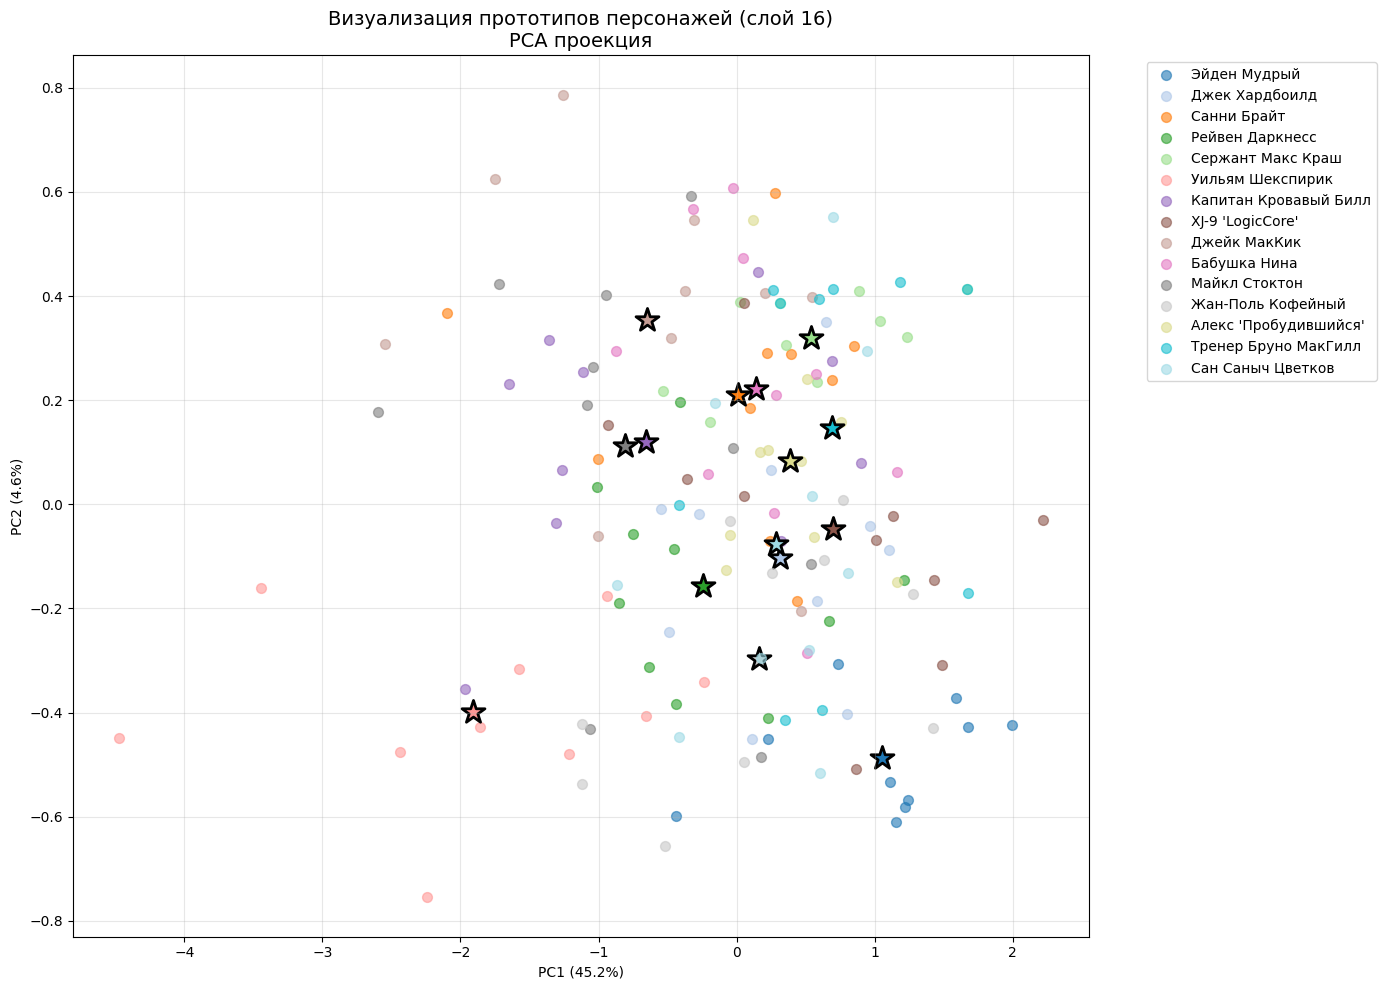

Объяснённая дисперсия: 49.8%


In [10]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import seaborn as sns

def visualize_prototypes(manager, layer_idx=16):
    """Визуализирует прототипы в 2D с помощью PCA."""
    
    # Собираем все эмбеддинги
    all_embeddings = []
    labels = []
    colors = []
    
    color_map = plt.cm.tab20(np.linspace(0, 1, len(manager.prototypes)))
    
    for idx, (char_id, prototype) in enumerate(manager.prototypes.items()):
        embeddings = prototype.embeddings[layer_idx]
        all_embeddings.append(embeddings)
        labels.extend([char_id] * len(embeddings))
        colors.extend([color_map[idx]] * len(embeddings))
    
    all_embeddings = np.vstack(all_embeddings)
    
    # PCA для снижения размерности
    pca = PCA(n_components=2)
    embeddings_2d = pca.fit_transform(all_embeddings)
    
    # Визуализация
    plt.figure(figsize=(14, 10))
    
    # Рисуем точки
    unique_labels = list(manager.prototypes.keys())
    for idx, char_id in enumerate(unique_labels):
        mask = np.array(labels) == char_id
        prototype = manager.get_prototype(char_id)
        plt.scatter(
            embeddings_2d[mask, 0],
            embeddings_2d[mask, 1],
            c=[color_map[idx]],
            label=prototype.name,
            alpha=0.6,
            s=50
        )
        
        # Рисуем центроид
        centroid = prototype.mu[layer_idx]
        centroid_2d = pca.transform(centroid.reshape(1, -1))[0]
        plt.scatter(
            centroid_2d[0], centroid_2d[1],
            c=[color_map[idx]],
            marker='*',
            s=300,
            edgecolors='black',
            linewidths=2
        )
    
    plt.title(f'Визуализация прототипов персонажей (слой {layer_idx})\nPCA проекция', fontsize=14)
    plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
    plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    print(f"Объяснённая дисперсия: {pca.explained_variance_ratio_.sum()*100:.1f}%")

# Визуализация
visualize_prototypes(manager, layer_idx=16)

## 12. Сравнение с базовой линией (без стиринга)

In [11]:
def compare_with_baseline(steering, prompt, character_id, alpha=0.35):
    """Сравнивает генерацию со стирингом и без."""
    
    print(f"Промпт: {prompt}\n")
    
    # Базовая генерация
    print("-" * 40)
    print("БЕЗ СТИРИНГА (базовая модель):")
    print("-" * 40)
    baseline = steering.generate_baseline(prompt, max_new_tokens=80, temperature=0.7)
    print(baseline)
    
    # Со стирингом
    prototype = manager.get_prototype(character_id)
    print("\n" + "-" * 40)
    print(f"СО СТИРИНГОМ ({prototype.name}, alpha={alpha}):")
    print("-" * 40)
    steered = steering.generate_with_steering(
        prompt=prompt,
        character_id=character_id,
        max_new_tokens=80,
        temperature=0.7,
        alpha=alpha
    )
    print(steered)

# Сравнение
test_prompt = """User: Как мне справиться с неудачами?
Assistant:"""

compare_with_baseline(steering, test_prompt, "drill_sergeant", alpha=0.4)

Промпт: User: Как мне справиться с неудачами?
Assistant:

----------------------------------------
БЕЗ СТИРИНГА (базовая модель):
----------------------------------------
I'm glad you're reaching out for advice on handling setbacks. Here are some suggestions that might help you:

1. Reframe your mindset: Instead of viewing setbacks as failures, consider them as learning experiences. Understand that everyone encounters challenges and that they're a natural part of the growth process.

2. Focus on progress, not perfection

----------------------------------------
СО СТИРИНГОМ (Сержант Макс Краш, alpha=0.4):
----------------------------------------
I'm here to help you deal with setbacks and failures. Here are some suggestions:

1. Reframe your perspective: Instead of seeing a failure as a defeat, try to view it as a learning opportunity. What can you take away from this experience that will help you in the future?

2. Stay positive: Maintain a positive attitude, even when things


## 14. Эксперименты с параметрами стиринга

In [ ]:
# Исследуем влияние параметра alpha (сила стиринга)

def alpha_experiment(steering, manager, prompt, character_id, alphas=[0.1, 0.2, 0.3, 0.4, 0.5, 0.7]):
    """Сравнивает разные значения alpha."""
    
    prototype = manager.get_prototype(character_id)
    print(f"Персонаж: {prototype.name}")
    print(f"Промпт: {prompt}\n")
    
    for alpha in alphas:
        print(f"\n{'='*60}")
        print(f"Alpha = {alpha} (сила стиринга)")
        print(f"{'='*60}")
        response = steering.generate_with_steering(
            prompt=prompt,
            character_id=character_id,
            max_new_tokens=60,
            temperature=0.7,
            alpha=alpha
        )
        print(response)

# Эксперимент
test_prompt = """User: Я боюсь неудач.
Assistant:"""

alpha_experiment(steering, manager, test_prompt, "sports_coach")

## 15. Сохранение и загрузка прототипов

In [ ]:
import pickle
import os

def save_prototypes(manager, filepath="/content/drive/MyDrive/character_prototypes.pkl"):
    """Сохраняет прототипы на диск."""
    data = {
        'prototypes': {},
        'metadata': {
            'model': MODEL_NAME,
            'layers': extractor.target_layers,
            'covariance_structure': 'diagonal'
        }
    }
    
    for char_id, proto in manager.prototypes.items():
        data['prototypes'][char_id] = {
            'name': proto.name,
            'traits': proto.traits,
            'mu': proto.mu,
            'sigma': proto.sigma,
            'embeddings': proto.embeddings
        }
    
    with open(filepath, 'wb') as f:
        pickle.dump(data, f)
    
    print(f"Прототипы сохранены: {filepath}")
    print(f"Размер файла: {os.path.getsize(filepath) / 1024**2:.1f} MB")

def load_prototypes(filepath="/content/drive/MyDrive/character_prototypes.pkl"):
    """Загружает прототипы с диска."""
    with open(filepath, 'rb') as f:
        data = pickle.load(f)
    
    print(f"Прототипы загружены из: {filepath}")
    print(f"Персонажей: {len(data['prototypes'])}")
    print(f"Модель: {data['metadata']['model']}")
    
    return data